In [5]:
import numpy as np
import pandas as pd
from scipy import stats

from tqdm import tqdm

import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

# Optimal A/B Test Split

It's often argued that a 50:50 split in A/B tests is optimal as it maximizes power.

This is true, but only if variances in the treatment and control groups are equal.

What happens when the treatment provokes polarizing reactions and inflates variance?


This is part of the [CausalPython](https://causalpython.io) series on causality.

<a href="https://causalpython.io"><img src="img/CausalPython.io__flat.png" width=150 align="left"></a>

<br>

## Define helpers

In [6]:
def welch_power(n_total, frac_treat, mu_c, mu_t, sd_c, sd_t, alpha=0.05):
    """
    Compute the theoretical power of a two-sided Welch's t-test.
    
    Parameters
    ----------
    n_total    : Total sample size across both groups.
    frac_treat : Fraction of total sample allocated to treatment (0, 1).
    mu_c, mu_t : Population means for control and treatment.
    sd_c, sd_t : Population standard deviations for control and treatment.
    alpha      : Significance level (two-sided).
    
    Returns
    -------
    power : float
    """
    n_t = max(n_total * frac_treat, 2)
    n_c = max(n_total * (1 - frac_treat), 2)
    
    # Standard error of the difference in means
    se = np.sqrt(sd_c**2 / n_c + sd_t**2 / n_t)
    
    # Welch-Satterthwaite degrees of freedom
    num = (sd_c**2 / n_c + sd_t**2 / n_t) ** 2
    den = (sd_c**2 / n_c)**2 / (n_c - 1) + (sd_t**2 / n_t)**2 / (n_t - 1)
    df = num / den
    
    # Noncentrality parameter
    delta = (mu_t - mu_c) / se
    
    # Critical value under the null
    t_crit = stats.t.ppf(1 - alpha / 2, df)
    
    # Power from noncentral t-distribution
    power = 1 - stats.nct.cdf(t_crit, df, delta) + stats.nct.cdf(-t_crit, df, delta)
    
    return power

In [7]:
def neyman_optimal_frac(sd_c, sd_t):
    """Optimal treatment fraction under Neyman allocation."""
    return sd_t / (sd_c + sd_t)

In [8]:
# Sanity checks
print(f"Power (equal var, 50/50):   {welch_power(1000, 0.5, 50, 55, 30, 30):.4f}")
print(f"Power (equal var, 70/30):   {welch_power(1000, 0.7, 50, 55, 30, 30):.4f}")
print(f"Power (unequal var, 50/50): {welch_power(1000, 0.5, 50, 55, 30, 60):.4f}")
print(f"Power (unequal var, 70/30): {welch_power(1000, 0.7, 50, 55, 30, 60):.4f}")

Power (equal var, 50/50):   0.7494
Power (equal var, 70/30):   0.6741
Power (unequal var, 50/50): 0.3840
Power (unequal var, 70/30): 0.4171


## Neyman allocation

Under **Neyman allocation**, the optimal fraction allocated to the treatment group is:

$$f^*_{\text{treatment}} = \frac{\sigma_{\text{treatment}}}{\sigma_{\text{control}} + \sigma_{\text{treatment}}}$$

When $\sigma_{\text{treatment}} = \sigma_{\text{control}}$, this simplifies to $f^* = 0.5$ (the familiar even split).

When the treatment group has higher variance, Neyman allocation assigns more units to it.

## Study setup

**Scenario:** An e-commerce platform A/B tests an **AI shopping assistant**.

- **Control group** shops as usual. Average order value: 50, with SD = 30.
- **Treatment group** interacts with the AI assistant before checkout.

The assistant lifts average order value by 5 (to 55), but it's *polarizing*:
some users love the personalized recommendations and spend significantly more,
while others find it intrusive and disengage, inflating the treatment group's variance.

We fix the total sample at $N=1{,}500$ and examine how **power** changes as a function of:
1. The **treatment allocation fraction** (how many users see the assistant), and
2. The **variance ratio** $\sigma_{\text{treatment}} / \sigma_{\text{control}}$ (how polarizing the assistant is).

## Compute power across allocation fractions and variance ratios

In [9]:
# Params
N_TOTAL = 1500
MU_C = 50
MU_T = 55
SD_C = 30

# Grid
fracs = np.linspace(0.05, 0.95, 200)
variance_ratios = np.linspace(0.1, 3.0, 200)

# Compute power for every combination
power_grid = np.zeros((len(variance_ratios), len(fracs)))

for i, vr in tqdm(enumerate(variance_ratios)):
    sd_t = SD_C * vr
    for j, f in enumerate(fracs):
        power_grid[i, j] = welch_power(N_TOTAL, f, MU_C, MU_T, SD_C, sd_t)

# For each variance ratio, find the allocation that maximizes power
optimal_fracs = fracs[np.argmax(power_grid, axis=1)]

# Neyman allocation prediction
neyman_fracs = np.array([neyman_optimal_frac(SD_C, SD_C * vr) for vr in variance_ratios])

200it [00:14, 13.36it/s]


## Visualize

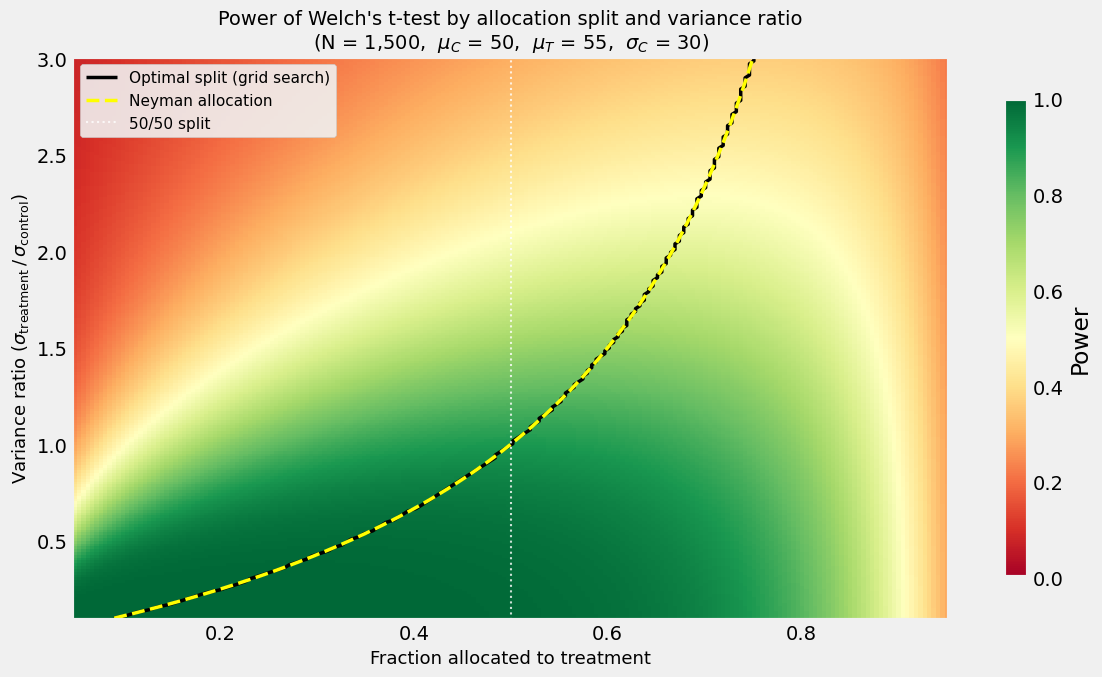

In [10]:
fig, ax = plt.subplots(figsize=(12, 7))

# Heatmap
im = ax.pcolormesh(
    fracs, variance_ratios, power_grid,
    cmap='RdYlGn', shading='auto', vmin=0, vmax=1
)

# Overlay: empirical optimum (from grid search)
ax.plot(
    optimal_fracs, variance_ratios,
    color='black', lw=2.5, ls='-',
    label='Optimal split (grid search)'
)

# Overlay: Neyman allocation
ax.plot(
    neyman_fracs, variance_ratios,
    color='yellow', lw=2.5, ls='--',
    label='Neyman allocation'
)

# 50/50 reference
ax.axvline(0.5, color='white', lw=1.5, ls=':', alpha=0.8, label='50/50 split')

# Formatting
cb = fig.colorbar(im, ax=ax, label='Power', shrink=0.85)
ax.set_xlabel('Fraction allocated to treatment', fontsize=13)
ax.set_ylabel(
    r'Variance ratio ($\sigma_{\mathrm{treatment}}\, /\, \sigma_{\mathrm{control}}$)',
    fontsize=13
)
ax.set_title(
    f'Power of Welch\'s t-test by allocation split and variance ratio\n'
    f'(N = {N_TOTAL:,},  $\\mu_C$ = {MU_C},  $\\mu_T$ = {MU_T},  $\\sigma_C$ = {SD_C})',
    fontsize=14
)
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

### Cross-sections at selected variance ratios

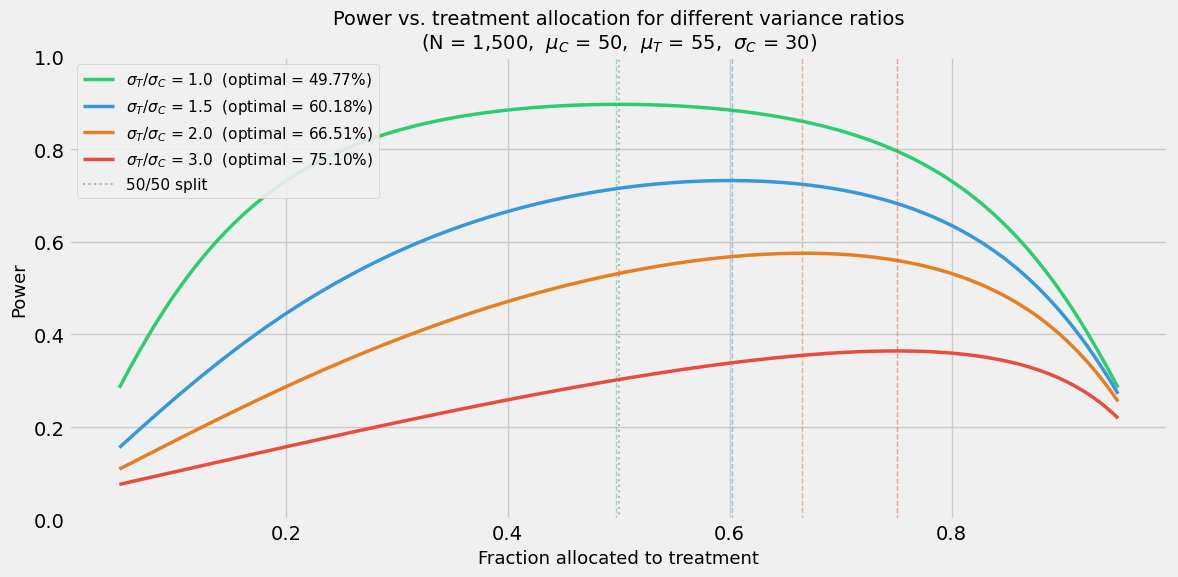

In [12]:
selected_ratios = [1.0, 1.5, 2.0, 3.0]
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))

for vr, color in zip(selected_ratios, colors):
    powers = [welch_power(N_TOTAL, f, MU_C, MU_T, SD_C, SD_C * vr) for f in fracs]
    
    # Peak
    best_frac = fracs[np.argmax(powers)]
    
    ax.plot(
        fracs, powers,
        color=color, lw=2.5,
        label=f'$\\sigma_T / \\sigma_C$ = {vr:.1f}  (optimal = {best_frac:.2%})'
    )
    ax.axvline(best_frac, color=color, ls='--', lw=1, alpha=0.5)

ax.axvline(0.5, color='gray', ls=':', lw=1.5, alpha=0.5, label='50/50 split')

ax.set_xlabel('Fraction allocated to treatment', fontsize=13)
ax.set_ylabel('Power', fontsize=13)
ax.set_title(
    f'Power vs. treatment allocation for different variance ratios\n'
    f'(N = {N_TOTAL:,},  $\\mu_C$ = {MU_C},  $\\mu_T$ = {MU_T},  $\\sigma_C$ = {SD_C})',
    fontsize=14
)
ax.legend(fontsize=11, framealpha=0.9)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()